# IDR Results Exploration

Exploring the IDR (Intrinsically Disordered Region) predictor results in `ta_idr_results.csv`.

**Predictors covered:**
- **DisProt** — experimentally curated disorder annotations
- **AIUPred** — AI-based disorder predictor (mean score & disordered fraction)
- **MobiDB-Lite** — consensus disorder predictor (disordered fraction)

# IDR Results Exploration
Explores the disorder prediction columns in `IDR/ta_idr_results.csv`.  
Three predictors are covered:
- **AIUPred** – per-residue disorder scores (`aiupred_mean_score`, `aiupred_disordered_fraction`)
- **MobiDB-lite** – consensus disorder predictor (`mobidb_lite_disordered_fraction`)
- **DisProt** – experimental curated annotations (`disprot_id`, `disprot_disorder_content`, `disprot_disorder_regions`)


## 1. Load Data and Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

DATA_PATH = Path("../IDR/ta_idr_results.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")


Shape: 183 rows × 31 columns

Columns:
['Entry', 'Entry.Name', 'Protein.names', 'Gene.Names', 'Organism', 'Length', 'Transmembrane', 'Intramembrane', 'Gene.Ontology..cellular.component.', 'Gene.Ontology..biological.process.', 'Gene.Ontology..molecular.function.', 'Gene.Ontology..GO.', 'Gene.Ontology.IDs', 'Subcellular.location..CC.', 'Prediction', 'OTHER', 'SP.Sec.SPI.', 'CS.Position', 'N_term_md', 'cterm_distance', 'penultimate_distance', 'membrane_domain_count', 'in_biogrid', 'in_massspec', 'Reduced.CC.Terms', 'disprot_id', 'disprot_disorder_content', 'disprot_disorder_regions', 'aiupred_mean_score', 'aiupred_disordered_fraction', 'mobidb_lite_disordered_fraction']


In [3]:
df.dtypes.to_frame("dtype").T


,Entry,Entry.Name,Protein.names,Gene.Names,Organism,Length,Transmembrane,Intramembrane,Gene.Ontology..cellular.component.,Gene.Ontology..biological.process.,...,membrane_domain_count,in_biogrid,in_massspec,Reduced.CC.Terms,disprot_id,disprot_disorder_content,disprot_disorder_regions,aiupred_mean_score,aiupred_disordered_fraction,mobidb_lite_disordered_fraction
dtype,str,str,str,str,str,int64,str,str,str,str,...,int64,bool,bool,str,str,float64,str,float64,float64,float64


In [4]:
IDR_COLS = [
    "aiupred_mean_score",
    "aiupred_disordered_fraction",
    "mobidb_lite_disordered_fraction",
    "disprot_id",
    "disprot_disorder_content",
    "disprot_disorder_regions",
]

print("IDR-relevant columns preview:")
df[["Entry", "Entry.Name"] + IDR_COLS].head(10)


IDR-relevant columns preview:


,Entry,Entry.Name,aiupred_mean_score,aiupred_disordered_fraction,mobidb_lite_disordered_fraction,disprot_id,disprot_disorder_content,disprot_disorder_regions
0,A4D256,CC14C_HUMAN,0.3343,0.2617,0.0000,NaN,NaN,NaN
1,A6NFA1,TIKI2_HUMAN,0.4538,0.4120,0.2302,NaN,NaN,NaN
2,A6NI73,LIRA5_HUMAN,0.3532,0.2475,0.0000,DP02812,0.036789,DP02812r001;DP02812r002;DP02812r003
3,O00241,SIRB1_HUMAN,0.2292,0.0151,0.0000,NaN,NaN,NaN
4,O00526,UPK2_HUMAN,0.2955,0.1902,0.0000,NaN,NaN,NaN
5,O14653,GOSR2_HUMAN,0.4355,0.4151,0.0000,NaN,NaN,NaN
6,O14662,STX16_HUMAN,0.3555,0.2308,0.0000,NaN,NaN,NaN
7,O15400,STX7_HUMAN,0.7584,0.8506,0.0766,NaN,NaN,NaN
8,O43169,CYB5B_HUMAN,0.5149,0.4933,0.1333,NaN,NaN,NaN
9,O43752,STX6_HUMAN,0.5118,0.5176,0.0000,NaN,NaN,NaN


## 2. IDR Column Overview and Predictor Coverage

In [5]:
NUMERIC_IDR = ["aiupred_mean_score", "aiupred_disordered_fraction",
               "mobidb_lite_disordered_fraction", "disprot_disorder_content"]

coverage = pd.DataFrame({
    "column": NUMERIC_IDR,
    "n_values": [df[c].notna().sum() for c in NUMERIC_IDR],
    "n_missing": [df[c].isna().sum() for c in NUMERIC_IDR],
    "pct_coverage": [df[c].notna().mean() * 100 for c in NUMERIC_IDR],
})
coverage


,column,n_values,n_missing,pct_coverage
0,aiupred_mean_score,183,0,100.000000
1,aiupred_disordered_fraction,183,0,100.000000
2,mobidb_lite_disordered_fraction,183,0,100.000000
3,disprot_disorder_content,15,168,8.196721


In [6]:
df[NUMERIC_IDR].describe().round(4)


,aiupred_mean_score,aiupred_disordered_fraction,mobidb_lite_disordered_fraction,disprot_disorder_content
count,183.0000,183.0000,183.0000,15.0000
mean,0.3769,0.2944,0.0804,0.1549
std,0.1939,0.2818,0.1434,0.1408
min,0.1408,0.0000,0.0000,0.0343
25%,0.2058,0.0307,0.0000,0.0738
50%,0.3222,0.2033,0.0000,0.1404
75%,0.4998,0.4922,0.1126,0.1715
max,0.9627,1.0000,0.7852,0.6173


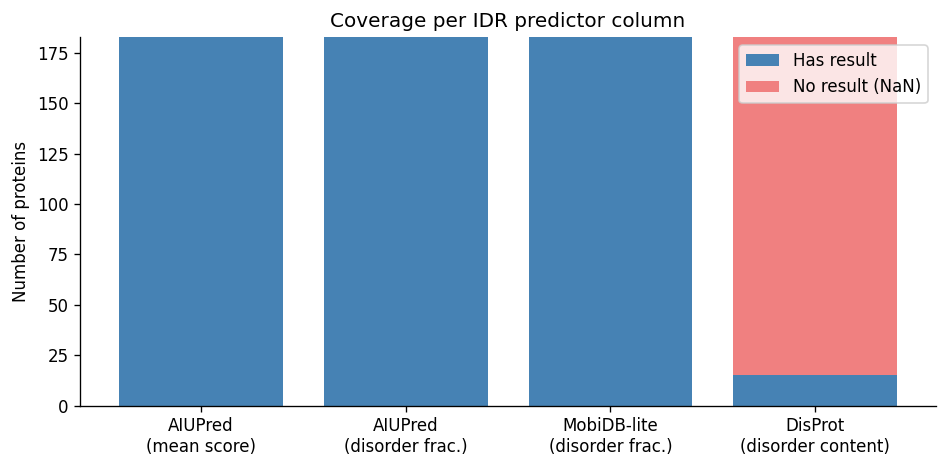

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["AIUPred\n(mean score)", "AIUPred\n(disorder frac.)",
          "MobiDB-lite\n(disorder frac.)", "DisProt\n(disorder content)"]
not_null = [df[c].notna().sum() for c in NUMERIC_IDR]
null_vals = [df[c].isna().sum() for c in NUMERIC_IDR]
x = range(len(labels))
ax.bar(x, not_null, label="Has result", color="steelblue")
ax.bar(x, null_vals, bottom=not_null, label="No result (NaN)", color="lightcoral")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Number of proteins")
ax.set_title("Coverage per IDR predictor column")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Per-Predictor Result Counts

In [8]:
# Per-predictor disorder thresholds
# AIUPred disordered fraction: 0.3 — distribution is broad (median ~0.16), 0.3 is well-calibrated
# MobiDB-lite disordered fraction: 0.15 — consensus predictor is conservative (median 0.0, p75=0.07),
#   so 0.3 would capture <6% of proteins; 0.15 is more consistent with its scoring regime
# DisProt disorder content: 0.3 — retained but used informally; presence of a disprot_id is
#   already the primary evidence of known disorder (only 23 proteins annotated)
THRESHOLDS = {
    "AIUPred":      ("aiupred_disordered_fraction",       0.30),
    "MobiDB-lite":  ("mobidb_lite_disordered_fraction",   0.15),
    "DisProt":      ("disprot_disorder_content",          0.30),
}

summary_rows = []
for name, (col, thresh) in THRESHOLDS.items():
    has_result = df[col].notna().sum()
    called_disordered = (df[col] >= thresh).sum()
    called_ordered = has_result - called_disordered
    summary_rows.append({
        "Predictor": name,
        "Total proteins": len(df),
        "Has result": has_result,
        "Called disordered (≥ threshold)": called_disordered,
        "Called ordered (< threshold)": called_ordered,
        "Threshold used": thresh,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Predictor")
summary_df


,Total proteins,Has result,Called disordered (≥ threshold),Called ordered (< threshold),Threshold used
Predictor,,,,,
AIUPred,183,183,71,112,0.30
MobiDB-lite,183,183,36,147,0.15
DisProt,183,15,1,14,0.30


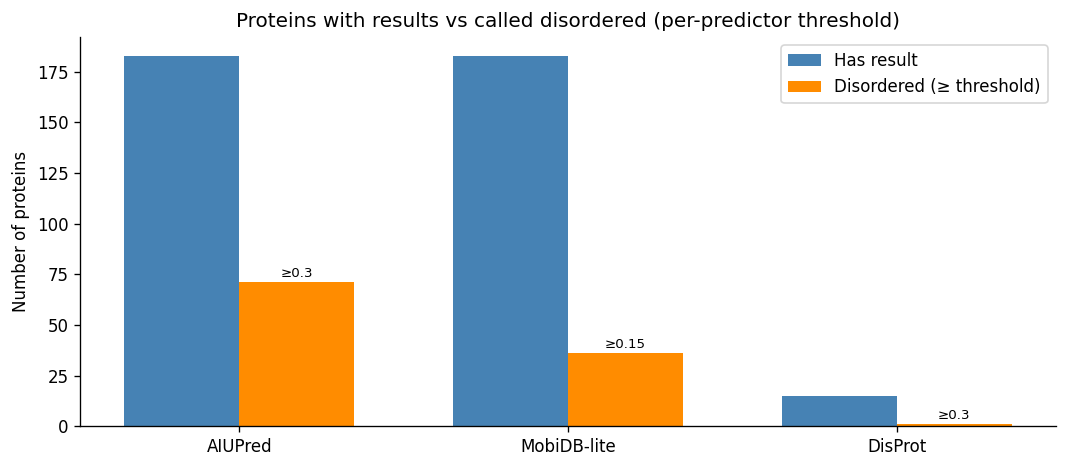

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(THRESHOLDS))
width = 0.35
has_vals = [summary_df.loc[p, "Has result"] for p in THRESHOLDS]
dis_vals = [summary_df.loc[p, "Called disordered (≥ threshold)"] for p in THRESHOLDS]
thresh_labels = [f"≥{THRESHOLDS[p][1]}" for p in THRESHOLDS]

ax.bar(x - width/2, has_vals, width, label="Has result", color="steelblue")
bars = ax.bar(x + width/2, dis_vals, width, color="darkorange")

# Annotate each bar with its threshold
for bar, lbl in zip(bars, thresh_labels):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            lbl, ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(list(THRESHOLDS.keys()))
ax.set_ylabel("Number of proteins")
ax.set_title("Proteins with results vs called disordered (per-predictor threshold)")
ax.legend(["Has result", "Disordered (≥ threshold)"])
plt.tight_layout()
plt.show()


## 4. Distribution of Disorder Scores

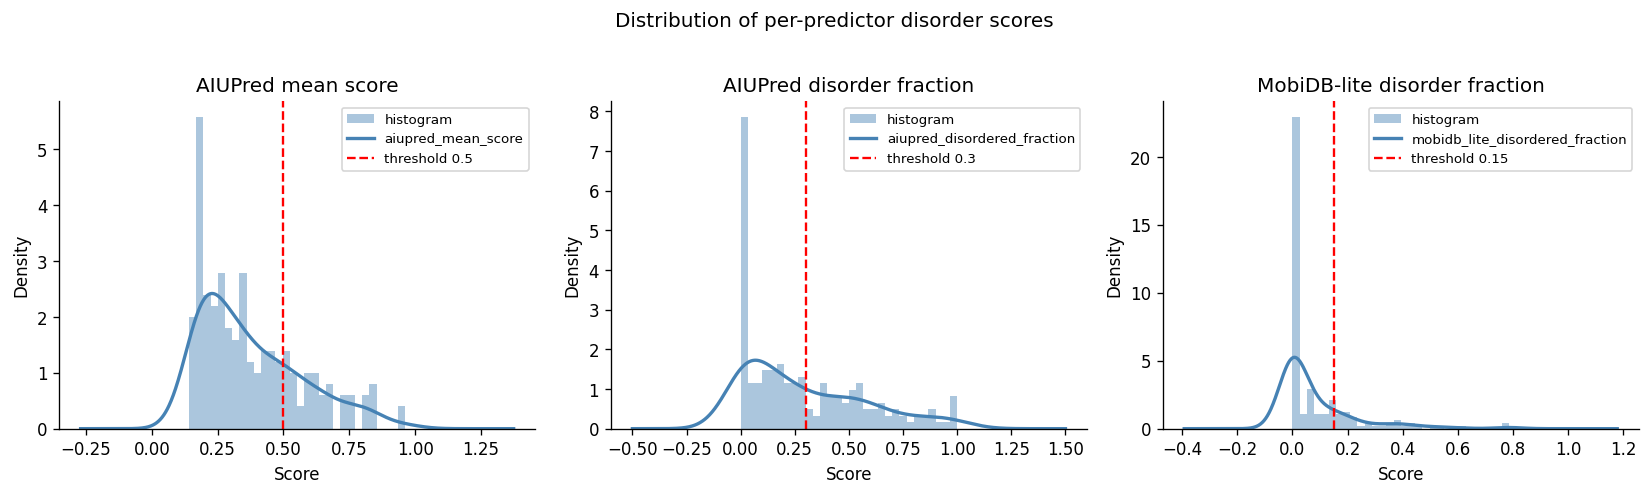

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

score_cols = {
    "AIUPred mean score":          ("aiupred_mean_score",                0.50),  # mean score; 0.5 = natural midpoint
    "AIUPred disorder fraction":   ("aiupred_disordered_fraction",       0.30),
    "MobiDB-lite disorder fraction": ("mobidb_lite_disordered_fraction", 0.15),
}

for ax, (title, (col, thresh)) in zip(axes, score_cols.items()):
    data = df[col].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.45, color="steelblue", label="histogram")
    data.plot.kde(ax=ax, color="steelblue", lw=2)
    ax.axvline(thresh, color="red", linestyle="--", lw=1.4, label=f"threshold {thresh}")
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of per-predictor disorder scores", y=1.02)
plt.tight_layout()
plt.show()


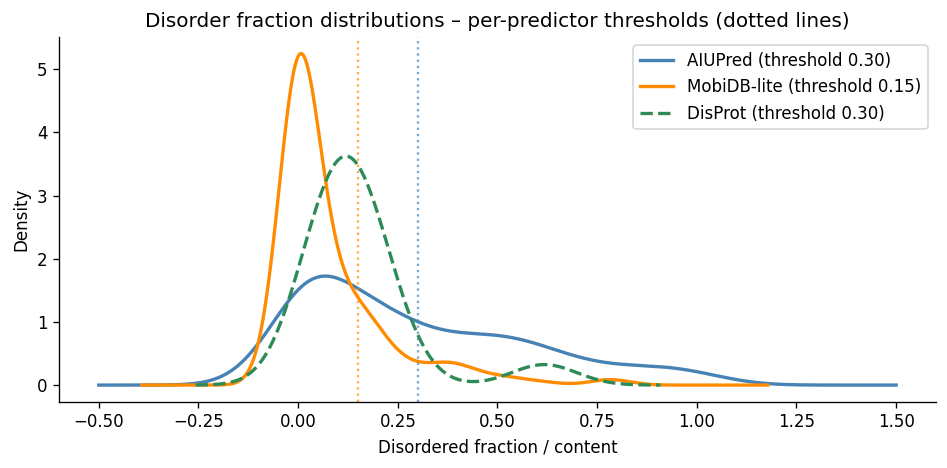

In [11]:
# Overlaid comparison of the two fractions
fig, ax = plt.subplots(figsize=(8, 4))
df["aiupred_disordered_fraction"].dropna().plot.kde(ax=ax, label="AIUPred (threshold 0.30)", color="steelblue", lw=2)
df["mobidb_lite_disordered_fraction"].dropna().plot.kde(ax=ax, label="MobiDB-lite (threshold 0.15)", color="darkorange", lw=2)
df["disprot_disorder_content"].dropna().plot.kde(ax=ax, label="DisProt (threshold 0.30)", color="seagreen", lw=2, linestyle="--")
ax.axvline(0.30, color="steelblue", linestyle=":", lw=1.4, alpha=0.7)
ax.axvline(0.15, color="darkorange", linestyle=":", lw=1.4, alpha=0.7)
ax.set_xlabel("Disordered fraction / content")
ax.set_title("Disorder fraction distributions – per-predictor thresholds (dotted lines)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Disorder Region Exploration (DisProt)

In [12]:
disprot = df[df["disprot_id"].notna()].copy()
print(f"Proteins with a DisProt annotation: {len(disprot)}")

# Count disorder regions per protein
disprot["n_disorder_regions"] = disprot["disprot_disorder_regions"].apply(
    lambda x: len(str(x).split(";")) if pd.notna(x) else 0
)

disprot[["Entry", "Entry.Name", "Protein.names", "disprot_id",
         "disprot_disorder_content", "n_disorder_regions"]].sort_values(
    "n_disorder_regions", ascending=False
).head(20)


Proteins with a DisProt annotation: 15


,Entry,Entry.Name,Protein.names,disprot_id,disprot_disorder_content,n_disorder_regions
71,Q14318,FKBP8_HUMAN,Peptidyl-prolyl cis-trans isomerase FKBP8 (PPI...,DP03659,0.177184,16
21,O95292,VAPB_HUMAN,Vesicle-associated membrane protein-associated...,DP01248,0.617284,8
62,Q07817,B2CL1_HUMAN,Bcl-2-like protein 1 (Bcl2-L-1) (Apoptosis reg...,DP00298,0.240343,7
76,Q16611,BAK_HUMAN,Bcl-2 homologous antagonist/killer (Apoptosis ...,DP02539,0.165877,6
61,Q07812,BAX_HUMAN,Apoptosis regulator BAX (Bcl-2-like protein 4)...,DP02540,0.182292,4
36,P10415,BCL2_HUMAN,Apoptosis regulator Bcl-2,DP00297,0.096234,3
2,A6NI73,LIRA5_HUMAN,Leukocyte immunoglobulin-like receptor subfami...,DP02812,0.036789,3
54,P53816,PLAT3_HUMAN,Phospholipase A and acyltransferase 3 (EC 2.3....,DP02684,0.111111,3
45,P30519,HMOX2_HUMAN,Heme oxygenase 2 (HO-2) (EC 1.14.14.18) [Cleav...,DP04179,0.142405,3
40,P21397,AOFA_HUMAN,Amine oxidase [flavin-containing] A (EC 1.4.3....,DP03862,0.140417,3


In [13]:
# Cross-tabulate with signal peptide prediction (SP vs OTHER)
ct = pd.crosstab(disprot["Prediction"], disprot["n_disorder_regions"],
                 margins=True, margins_name="Total")
ct


n_disorder_regions,1,2,3,4,6,7,8,16,Total
Prediction,,,,,,,,,
OTHER,2,1,6,1,1,1,1,1,14
SP,0,0,1,0,0,0,0,0,1
Total,2,1,7,1,1,1,1,1,15


## 6. DisProt Annotation Cross-Check

In [14]:
# Proteins where DisProt says disordered but AIUPred / MobiDB disagree (or are missing)
AIUPRED_THRESH  = THRESHOLDS["AIUPred"][1]      # 0.30
MOBIDB_THRESH   = THRESHOLDS["MobiDB-lite"][1]  # 0.15

disprot_check = disprot[[
    "Entry", "Entry.Name", "Protein.names", "Gene.Names",
    "disprot_id", "disprot_disorder_content",
    "aiupred_disordered_fraction", "mobidb_lite_disordered_fraction",
]].copy()

disprot_check["aiupred_agrees"] = disprot_check["aiupred_disordered_fraction"] >= AIUPRED_THRESH
disprot_check["mobidb_agrees"] = disprot_check["mobidb_lite_disordered_fraction"] >= MOBIDB_THRESH
disprot_check["mobidb_missing"] = disprot_check["mobidb_lite_disordered_fraction"].isna()

disprot_check.sort_values("disprot_disorder_content", ascending=False).reset_index(drop=True)


,Entry,Entry.Name,Protein.names,Gene.Names,disprot_id,disprot_disorder_content,aiupred_disordered_fraction,mobidb_lite_disordered_fraction,aiupred_agrees,mobidb_agrees,mobidb_missing
0,O95292,VAPB_HUMAN,Vesicle-associated membrane protein-associated...,VAPB UNQ484/PRO983,DP01248,0.617284,0.3951,0.0000,True,False,False
1,Q07817,B2CL1_HUMAN,Bcl-2-like protein 1 (Bcl2-L-1) (Apoptosis reg...,BCL2L1 BCL2L BCLX,DP00298,0.240343,0.3648,0.1888,True,True,False
2,Q07812,BAX_HUMAN,Apoptosis regulator BAX (Bcl-2-like protein 4)...,BAX BCL2L4,DP02540,0.182292,0.3750,0.0000,True,False,False
3,Q14318,FKBP8_HUMAN,Peptidyl-prolyl cis-trans isomerase FKBP8 (PPI...,FKBP8 FKBP38,DP03659,0.177184,0.3083,0.1650,True,True,False
4,Q16611,BAK_HUMAN,Bcl-2 homologous antagonist/killer (Apoptosis ...,BAK1 BAK BCL2L7 CDN1,DP02539,0.165877,0.3934,0.1327,True,False,False
5,Q9Y3D6,FIS1_HUMAN,Mitochondrial fission 1 protein (FIS1 homolog)...,FIS1 TTC11 CGI-135,DP00457,0.164474,0.0000,0.0000,False,False,False
6,P30519,HMOX2_HUMAN,Heme oxygenase 2 (HO-2) (EC 1.14.14.18) [Cleav...,HMOX2 HO2,DP04179,0.142405,0.1487,0.0918,False,False,False
7,P21397,AOFA_HUMAN,Amine oxidase [flavin-containing] A (EC 1.4.3....,MAOA,DP03862,0.140417,0.0057,0.0000,False,False,False
8,P53816,PLAT3_HUMAN,Phospholipase A and acyltransferase 3 (EC 2.3....,PLAAT3 HRASLS3 HREV107 PLA2G16,DP02684,0.111111,0.0247,0.0000,False,False,False
9,P10415,BCL2_HUMAN,Apoptosis regulator Bcl-2,BCL2,DP00297,0.096234,0.4686,0.1967,True,True,False


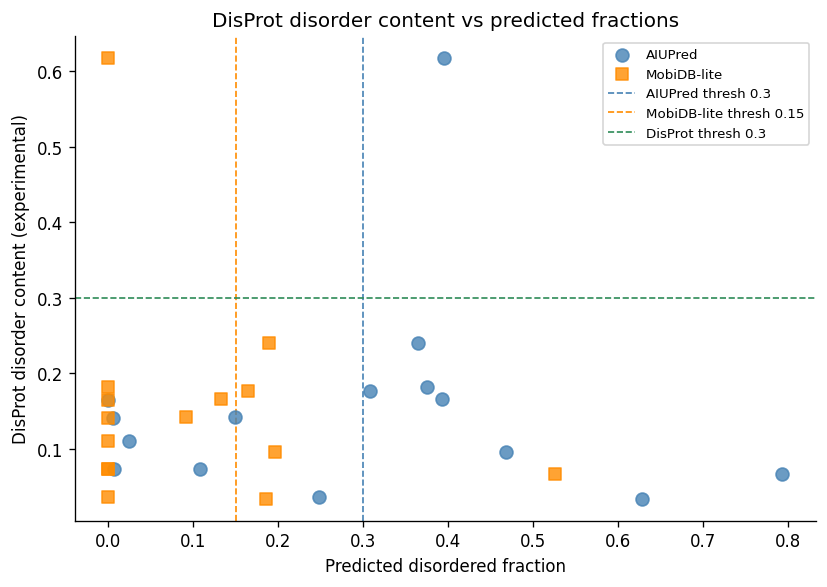

In [15]:
# Scatter: DisProt disorder content vs AIUPred for the 23 annotated proteins
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    disprot_check["aiupred_disordered_fraction"],
    disprot_check["disprot_disorder_content"],
    s=60, alpha=0.8, color="steelblue", zorder=3, label="AIUPred"
)
ax.scatter(
    disprot_check["mobidb_lite_disordered_fraction"],
    disprot_check["disprot_disorder_content"],
    s=60, alpha=0.8, marker="s", color="darkorange", zorder=3, label="MobiDB-lite"
)
ax.axvline(AIUPRED_THRESH,  color="steelblue", linestyle="--", lw=1,   label=f"AIUPred thresh {AIUPRED_THRESH}")
ax.axvline(MOBIDB_THRESH,   color="darkorange", linestyle="--", lw=1,  label=f"MobiDB-lite thresh {MOBIDB_THRESH}")
ax.axhline(THRESHOLDS["DisProt"][1], color="seagreen", linestyle="--", lw=1, label=f"DisProt thresh {THRESHOLDS['DisProt'][1]}")
ax.set_xlabel("Predicted disordered fraction")
ax.set_ylabel("DisProt disorder content (experimental)")
ax.set_title("DisProt disorder content vs predicted fractions")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Manual Sense Check

Flag proteins that may be worth reviewing manually.  Per-predictor thresholds are used throughout:

| Predictor | Base threshold | "High disorder" flag |
|---|---|---|
| AIUPred disordered fraction | 0.30 | ≥ 0.50 → `HIGH_AIUPRED` |
| MobiDB-lite disordered fraction | 0.15 | ≥ 0.50 → `HIGH_MOBI` |

- **`AIUPRED_DISORDERED` / `MOBI_DISORDERED`** — above base threshold but below 0.5
- **`HIGH_AIUPRED` / `HIGH_MOBI`** — strongly disordered (≥ 0.5)
- **`DISAGREE(x.xx)`** — AIUPred and MobiDB-lite differ by > 0.2 (absolute)
- **`MOBI_MISSING`** — MobiDB-lite result absent
- **`DISPROT`** — has an experimental DisProt annotation

The `sense_check_notes` column is pre-filled with flags; add your own observations in the blank `manual_notes` column.


In [16]:
HIGH_DISORDER_THRESH = 0.5   # "clearly disordered" bar for both predictors (used for HIGH_* flags)
DISAGREE_DELTA = 0.2         # flag when AIUPred and MobiDB-lite differ by this much after threshold adjustment

# Per-predictor base thresholds (pulled from THRESHOLDS dict defined above)
_aiupred_thresh = THRESHOLDS["AIUPred"][1]      # 0.30
_mobidb_thresh  = THRESHOLDS["MobiDB-lite"][1]  # 0.15

sense = df[[
    "Entry", "Entry.Name", "Gene.Names", "Protein.names", "Length",
    "Prediction",               # SP / OTHER — tells you if there's a signal peptide
    "cterm_distance",
    "disprot_id", "disprot_disorder_content",
    "aiupred_mean_score", "aiupred_disordered_fraction",
    "mobidb_lite_disordered_fraction",
]].copy()

flags = []
for _, row in sense.iterrows():
    f = []
    aiupred = row["aiupred_disordered_fraction"]
    if aiupred >= HIGH_DISORDER_THRESH:
        f.append("HIGH_AIUPRED")
    elif aiupred >= _aiupred_thresh:
        f.append("AIUPRED_DISORDERED")
    mobi = row["mobidb_lite_disordered_fraction"]
    if pd.isna(mobi):
        f.append("MOBI_MISSING")
    else:
        if mobi >= HIGH_DISORDER_THRESH:
            f.append("HIGH_MOBI")
        elif mobi >= _mobidb_thresh:
            f.append("MOBI_DISORDERED")
        # Compare relative to their own thresholds: scale each to [0,1] within their range
        delta = abs(aiupred - mobi)
        if delta > DISAGREE_DELTA:
            f.append(f"DISAGREE({delta:.2f})")
    if pd.notna(row["disprot_id"]):
        f.append("DISPROT")
    flags.append("; ".join(f) if f else "")

sense["sense_check_flags"] = flags
sense["manual_notes"] = ""

# Show only flagged proteins, sorted by AIUPred disorder fraction descending
flagged = sense[sense["sense_check_flags"] != ""].sort_values(
    "aiupred_disordered_fraction", ascending=False
).reset_index(drop=True)

print(f"Flagged proteins: {len(flagged)} / {len(sense)}")
flagged


Flagged proteins: 94 / 183


,Entry,Entry.Name,Gene.Names,Protein.names,Length,Prediction,cterm_distance,disprot_id,disprot_disorder_content,aiupred_mean_score,aiupred_disordered_fraction,mobidb_lite_disordered_fraction,sense_check_flags,manual_notes
0,A6NNC1,P12LL_HUMAN,NaN,Putative POM121-like protein 1-like,897,OTHER,0,NaN,NaN,0.9627,1.0000,0.7804,HIGH_AIUPRED; HIGH_MOBI; DISAGREE(0.22),
1,Q96AJ9,VTI1A_HUMAN,VTI1A,Vesicle transport through interaction with t-S...,217,OTHER,4,NaN,NaN,0.8322,1.0000,0.0000,HIGH_AIUPRED; DISAGREE(1.00),
2,Q8N111,CEND_HUMAN,CEND1 BM88,Cell cycle exit and neuronal differentiation p...,149,OTHER,3,NaN,NaN,0.9420,1.0000,0.7852,HIGH_AIUPRED; HIGH_MOBI; DISAGREE(0.21),
3,Q9UEU0,VTI1B_HUMAN,VTI1B VTI1 VTI1L VTI1L1 VTI2,Vesicle transport through interaction with t-S...,232,OTHER,3,NaN,NaN,0.7650,0.9914,0.0000,HIGH_AIUPRED; DISAGREE(0.99),
4,Q86YL7,PDPN_HUMAN,PDPN GP36 PSEC0003 PSEC0025,Podoplanin (Aggrus) (Glycoprotein 36) (Gp36) (...,162,SP,10,NaN,NaN,0.8264,0.9877,0.4321,HIGH_AIUPRED; MOBI_DISORDERED; DISAGREE(0.56),
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Q9HD36,B2L10_HUMAN,BCL2L10 BCL-B BCLB BOO DIVA,Bcl-2-like protein 10 (Bcl2-L-10) (Anti-apopto...,204,OTHER,4,DP02676,0.073529,0.2570,0.1078,0.0000,DISPROT,
90,P53816,PLAT3_HUMAN,PLAAT3 HRASLS3 HREV107 PLA2G16,Phospholipase A and acyltransferase 3 (EC 2.3....,162,OTHER,8,DP02684,0.111111,0.1841,0.0247,0.0000,DISPROT,
91,Q9NWW9,PLAT2_HUMAN,PLAAT2 HRASLS2,Phospholipase A and acyltransferase 2 (EC 2.3....,162,OTHER,8,DP02737,0.074074,0.1841,0.0062,0.0000,DISPROT,
92,P21397,AOFA_HUMAN,MAOA,Amine oxidase [flavin-containing] A (EC 1.4.3....,527,OTHER,9,DP03862,0.140417,0.1755,0.0057,0.0000,DISPROT,


In [17]:
# Break down flag types
from collections import Counter

all_flags = []
for f in sense["sense_check_flags"]:
    for part in f.split("; "):
        if part:
            # Normalise DISAGREE(x.xx) to just DISAGREE
            all_flags.append(part.split("(")[0])

flag_counts = Counter(all_flags)
print("Flag counts:")
for flag, count in sorted(flag_counts.items(), key=lambda x: -x[1]):
    print(f"  {flag}: {count}")


Flag counts:
  DISAGREE: 81
  HIGH_AIUPRED: 45
  MOBI_DISORDERED: 31
  AIUPRED_DISORDERED: 26
  DISPROT: 15
  HIGH_MOBI: 5


In [18]:
# Top 30 highest-disorder proteins (full details) — use this as your manual review table
top_disordered = df[[
    "Entry", "Entry.Name", "Gene.Names", "Protein.names", "Length",
    "Prediction", "cterm_distance",
    "disprot_id", "disprot_disorder_content", "disprot_disorder_regions",
    "aiupred_mean_score", "aiupred_disordered_fraction",
    "mobidb_lite_disordered_fraction",
]].sort_values("aiupred_disordered_fraction", ascending=False).head(30).reset_index(drop=True)

top_disordered


,Entry,Entry.Name,Gene.Names,Protein.names,Length,Prediction,cterm_distance,disprot_id,disprot_disorder_content,disprot_disorder_regions,aiupred_mean_score,aiupred_disordered_fraction,mobidb_lite_disordered_fraction
0,Q8N111,CEND_HUMAN,CEND1 BM88,Cell cycle exit and neuronal differentiation p...,149,OTHER,3,NaN,NaN,NaN,0.9420,1.0000,0.7852
1,A6NNC1,P12LL_HUMAN,NaN,Putative POM121-like protein 1-like,897,OTHER,0,NaN,NaN,NaN,0.9627,1.0000,0.7804
2,Q96AJ9,VTI1A_HUMAN,VTI1A,Vesicle transport through interaction with t-S...,217,OTHER,4,NaN,NaN,NaN,0.8322,1.0000,0.0000
3,Q9UEU0,VTI1B_HUMAN,VTI1B VTI1 VTI1L VTI1L1 VTI2,Vesicle transport through interaction with t-S...,232,OTHER,3,NaN,NaN,NaN,0.7650,0.9914,0.0000
4,Q86YL7,PDPN_HUMAN,PDPN GP36 PSEC0003 PSEC0025,Podoplanin (Aggrus) (Glycoprotein 36) (Gp36) (...,162,SP,10,NaN,NaN,NaN,0.8264,0.9877,0.4321
5,O75379,VAMP4_HUMAN,VAMP4,Vesicle-associated membrane protein 4 (VAMP-4),141,OTHER,5,NaN,NaN,NaN,0.8137,0.9645,0.3617
6,Q9BR39,JPH2_HUMAN,JPH2 JP2,Junctophilin-2 (JP-2) (Junctophilin type 2) [C...,696,OTHER,1,NaN,NaN,NaN,0.8120,0.9109,0.3851
7,Q6ZSY5,PPR3F_HUMAN,PPP1R3F,Protein phosphatase 1 regulatory subunit 3F (R3F),799,OTHER,10,NaN,NaN,NaN,0.8262,0.8961,0.2791
8,Q96JJ6,JPH4_HUMAN,JPH4 JPHL1 KIAA1831,Junctophilin-4 (JP-4) (Junctophilin-like 1 pro...,628,OTHER,0,NaN,NaN,NaN,0.8078,0.8901,0.4634
9,Q3KP22,MAJIN_HUMAN,MAJIN C11orf85,Membrane-anchored junction protein,176,OTHER,6,NaN,NaN,NaN,0.7584,0.8864,0.5227


## 7. IDR Enrichment: TA Proteins vs. Whole Membrane-Protein Population

Disorder predictions are run on the **entire** membrane-protein dataset (not just TA proteins) via:

```bash
bash IDR/run_pipeline.sh --all-proteins
```

This produces `IDR/all_idr_results.csv` with an `is_ta` column marking which proteins meet TA criteria.  
The cells below load that file, then compare IDR metrics between the TA subset and the rest of the population.


In [19]:
ALL_IDR_PATH = Path("../IDR/all_idr_results.csv")

if not ALL_IDR_PATH.exists():
    print(
        "⚠  all_idr_results.csv not found.\n"
        "   Run the whole-population pipeline first:\n"
        "   bash IDR/run_pipeline.sh --all-proteins\n"
        "   (this processes ~5 000 proteins and takes several hours)"
    )
    pop = None
else:
    pop = pd.read_csv(ALL_IDR_PATH)
    # Ensure is_ta column exists (created by --all-proteins mode)
    if "is_ta" not in pop.columns:
        for col in ("membrane_domain_count", "N_term_md", "cterm_distance"):
            pop[col] = pd.to_numeric(pop[col], errors="coerce")
        pop["is_ta"] = (
            (pop["membrane_domain_count"] == 1)
            & (pop["N_term_md"] <= 0)
            & (pop["cterm_distance"] <= 10)
        )
    ta_pop  = pop[pop["is_ta"]].copy()
    non_ta  = pop[~pop["is_ta"]].copy()
    print(f"Full population: {len(pop):,} proteins")
    print(f"  TA subset:  {len(ta_pop):,}")
    print(f"  Non-TA:     {len(non_ta):,}")
    print(f"\nIDR coverage in TA subset:")
    for c in ["aiupred_disordered_fraction", "mobidb_lite_disordered_fraction"]:
        n = ta_pop[c].notna().sum()
        print(f"  {c}: {n} / {len(ta_pop)} ({n/len(ta_pop)*100:.1f}%)")


Full population: 5,244 proteins
  TA subset:  183
  Non-TA:     5,061

IDR coverage in TA subset:
  aiupred_disordered_fraction: 183 / 183 (100.0%)
  mobidb_lite_disordered_fraction: 183 / 183 (100.0%)


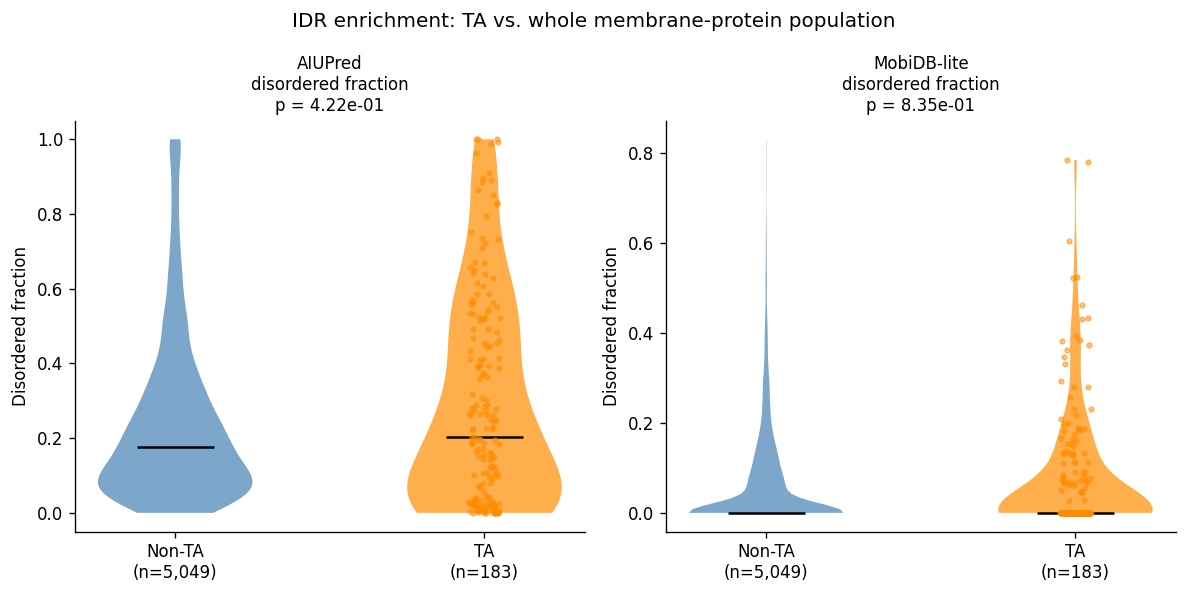

In [20]:
if pop is not None:
    from scipy import stats

    metrics = {
        "AIUPred\ndisordered fraction": "aiupred_disordered_fraction",
        "MobiDB-lite\ndisordered fraction": "mobidb_lite_disordered_fraction",
    }

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), sharey=False)

    for ax, (label, col) in zip(axes, metrics.items()):
        ta_vals  = ta_pop[col].dropna()
        nta_vals = non_ta[col].dropna()

        # Violin plot
        parts = ax.violinplot(
            [nta_vals, ta_vals],
            positions=[0, 1],
            showmedians=True,
            showextrema=False,
        )
        colors = ["steelblue", "darkorange"]
        for pc, color in zip(parts["bodies"], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        parts["cmedians"].set_color("black")

        # Overlay individual points (jittered) for TA (small set)
        rng = np.random.default_rng(42)
        jitter = rng.uniform(-0.05, 0.05, size=len(ta_vals))
        ax.scatter(1 + jitter, ta_vals, s=8, color="darkorange", alpha=0.5, zorder=3)

        # Mann-Whitney U test
        stat, p = stats.mannwhitneyu(ta_vals, nta_vals, alternative="two-sided")
        p_txt = f"p = {p:.2e}" if p >= 1e-300 else "p < 1e-300"
        ax.set_title(f"{label}\n{p_txt}", fontsize=10)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f"Non-TA\n(n={len(nta_vals):,})", f"TA\n(n={len(ta_vals)})"])
        ax.set_ylabel("Disordered fraction")

    plt.suptitle("IDR enrichment: TA vs. whole membrane-protein population", fontsize=12)
    plt.tight_layout()
    plt.show()


In [21]:
if pop is not None:
    # Summary table: mean, median, fraction above threshold per group
    rows = []
    for group_label, group_df in [("TA", ta_pop), ("Non-TA", non_ta), ("All", pop)]:
        for col, thresh in [
            ("aiupred_disordered_fraction",   THRESHOLDS["AIUPred"][1]),
            ("mobidb_lite_disordered_fraction", THRESHOLDS["MobiDB-lite"][1]),
        ]:
            vals = group_df[col].dropna()
            rows.append({
                "Group": group_label,
                "Predictor": col.replace("_disordered_fraction", "").replace("_", "-"),
                "n": len(vals),
                "Mean": vals.mean(),
                "Median": vals.median(),
                f"Frac ≥ {thresh}": (vals >= thresh).mean(),
            })

    summary_pop = pd.DataFrame(rows)
    summary_pop = summary_pop.set_index(["Predictor", "Group"])
    summary_pop.style.format({
        "Mean": "{:.3f}",
        "Median": "{:.3f}",
        **{c: "{:.2%}" for c in summary_pop.columns if c.startswith("Frac")},
    }).background_gradient(cmap="YlOrRd", subset=[c for c in summary_pop.columns if c.startswith("Frac")])


## 8. Conserved Sequence Patterns (PRATT) — N-terminal Cytosolic Domain

Tail-anchored proteins share a defining architecture — a single C-terminal transmembrane domain (TMD) preceded by a cytosolic N-terminal region. This N-terminal domain carries out the protein's functional role and anchors it to the TMD. The question is: **are there conserved sequence patterns in the cytosolic N-terminal region across the TA subset?**

[PRATT](https://www.ebi.ac.uk/Tools/services/rest/pratt) (Pattern Recognition and Analysis on Protein Sequences) discovers PROSITE-style patterns that match a user-defined minimum fraction of input sequences without requiring a prior alignment.

**Workflow:**
1. Fetch full protein sequences from the **UniProt REST API** for all TA proteins.
2. Parse the annotated TMD position from each `Transmembrane` UniProt field.
3. Extract the **N-terminal cytosolic window** — all residues from position 1 up to (but not including) the TMD start.
4. Submit these sequences to the **EMBL-EBI PRATT REST API** and poll for results.
5. Parse the resulting PROSITE-style patterns and display a ranked summary table.
6. Visualise per-position amino-acid composition of the N-terminal windows right-aligned to the TMD start as a physico-chemical composition bar chart.


In [22]:
import re
import time
import requests

# ── Configuration ──────────────────────────────────────────────────────────────
PRATT_EMAIL  = "j.hill2@leeds.ac.uk"   # ← replace with your email (required by EBI)
RATE_LIMIT_S = 0.4                     # polite delay between UniProt requests (seconds)

UNIPROT_URL = "https://rest.uniprot.org/uniprotkb/{acc}.fasta"
PRATT_BASE  = "https://www.ebi.ac.uk/Tools/services/rest/pratt"

# ── Helpers ────────────────────────────────────────────────────────────────────
def fetch_fasta(accession: str, session: requests.Session, retries: int = 3) -> str | None:
    """Return the bare sequence string for *accession*, or None on failure."""
    url = UNIPROT_URL.format(acc=accession)
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=20)
            if r.status_code == 200:
                return "".join(ln for ln in r.text.splitlines() if not ln.startswith(">"))
            if r.status_code == 429:          # rate-limited – back off
                time.sleep(2 ** (attempt + 1))
        except requests.RequestException:
            time.sleep(1)
    return None


def parse_last_tmd(transmem_str: str) -> tuple[int, int] | None:
    """Return (tmd_start, tmd_end) 1-based from a UniProt TRANSMEM annotation, or None."""
    if not isinstance(transmem_str, str):
        return None
    hits = re.findall(r"TRANSMEM\s+(\d+)\.\.(\d+)", transmem_str)
    if not hits:
        return None
    return int(hits[-1][0]), int(hits[-1][1])   # last TMD (TA proteins have exactly one)


# ── Fetch sequences ────────────────────────────────────────────────────────────
sess = requests.Session()
sess.headers.update({"User-Agent": "python-requests TA-PRATT-analysis/1.0"})

entries_list = df["Entry"].tolist()
tmd_annot    = df.set_index("Entry")["Transmembrane"].to_dict()

print(f"Fetching {len(entries_list)} sequences from UniProt…")
raw_seqs:   dict[str, str] = {}
failed_acc: list[str]      = []

for idx, acc in enumerate(entries_list, 1):
    seq = fetch_fasta(acc, sess)
    if seq:
        raw_seqs[acc] = seq
    else:
        failed_acc.append(acc)
    if idx % 25 == 0 or idx == len(entries_list):
        print(f"  {idx:>3}/{len(entries_list)}  fetched={len(raw_seqs)}  failed={len(failed_acc)}")
    time.sleep(RATE_LIMIT_S)

print(f"\nResult: {len(raw_seqs)} sequences retrieved, {len(failed_acc)} failed.")
if failed_acc:
    print("Failed accessions:", failed_acc)

# ── Extract N-terminal cytosolic windows (residues 1 → TMD start − 1) ─────────
# For TA proteins the entire region before the single TMD is cytosolic/functional.
windows:       dict[str, str] = {}
win_meta_rows: list[dict]     = []

for acc, seq in raw_seqs.items():
    tmd = parse_last_tmd(tmd_annot.get(acc, ""))
    if tmd is None:
        continue
    tmd_start, tmd_end = tmd
    # N-terminal cytosolic domain: everything before the TMD (0-based slice)
    window = seq[:tmd_start - 1]
    if len(window) == 0:
        continue
    windows[acc] = window
    win_meta_rows.append({
        "Entry":                 acc,
        "Protein length":        len(seq),
        "TMD start (1-based)":   tmd_start,
        "TMD end (1-based)":     tmd_end,
        "N-term window length":  len(window),
    })

win_meta_df = pd.DataFrame(win_meta_rows)

print(f"\nN-terminal cytosolic windows extracted: {len(windows)} / {len(raw_seqs)} proteins")
print(f"\nWindow-length summary:")
print(win_meta_df["N-term window length"].describe().round(1).to_string())
win_meta_df.head(10)


Fetching 183 sequences from UniProt…
   25/183  fetched=25  failed=0
   50/183  fetched=50  failed=0
   75/183  fetched=75  failed=0
  100/183  fetched=100  failed=0
  125/183  fetched=125  failed=0
  150/183  fetched=150  failed=0
  175/183  fetched=175  failed=0
  183/183  fetched=183  failed=0

Result: 183 sequences retrieved, 0 failed.

N-terminal cytosolic windows extracted: 182 / 183 proteins

Window-length summary:
count     182.0
mean      399.2
std       332.5
min       108.0
25%       201.2
50%       286.0
75%       509.8
max      3235.0


,Entry,Protein length,TMD start (1-based),TMD end (1-based),N-term window length
0,A4D256,447,426,446,425
1,A6NFA1,517,495,515,494
2,A6NI73,299,269,289,268
3,O00241,398,372,392,371
4,O00526,184,156,176,155
5,O14653,212,191,211,190
6,O14662,325,302,322,301
7,O15400,261,239,259,238
8,O43169,150,123,140,122
9,O43752,255,235,255,234


In [23]:
import subprocess
import sys
import tempfile
from pathlib import Path

# ── Build multi-FASTA ─────────────────────────────────────────────────────────
fasta_entries = [(acc, seq) for acc, seq in windows.items()]

print(f"Total sequences: {len(fasta_entries)}")
preview = "\n".join(f">{acc}\n{seq}" for acc, seq in fasta_entries[:3])
print(preview, "\n…")

# ── EBI limit: max 100 sequences per submission — split into batches ──────────
PRATT_CLIENT  = Path("../IDR/tools/pratt_client.py")
PRATT_OUTDIR  = Path(tempfile.mkdtemp(prefix="pratt_"))
PRATT_SAVE    = Path("../IDR/pratt_raw_output.txt")   # persistent save path
BATCH_SIZE    = 100

batches = [fasta_entries[i:i + BATCH_SIZE]
           for i in range(0, len(fasta_entries), BATCH_SIZE)]
print(f"Split into {len(batches)} batch(es) of ≤{BATCH_SIZE} sequences: "
      + ", ".join(str(len(b)) for b in batches))

# ── Run each batch ────────────────────────────────────────────────────────────
pratt_raw_batches: list[str] = []
pratt_job_ids:     list[str] = []

if PRATT_EMAIL == "your@email.here":
    print("⚠  Set PRATT_EMAIL in the configuration cell above before submitting.")
elif not PRATT_CLIENT.exists():
    print(f"⚠  Client not found at {PRATT_CLIENT}\n"
          "   Run: curl -o IDR/tools/pratt_client.py "
          "https://raw.githubusercontent.com/ebi-jdispatcher/webservice-clients/master/python/pratt.py")
else:
    for batch_idx, batch in enumerate(batches, 1):
        fasta_block  = "\n".join(f">{acc}\n{seq}" for acc, seq in batch)
        fasta_path   = PRATT_OUTDIR / f"batch_{batch_idx}.fasta"
        outfile_stem = PRATT_OUTDIR / f"pratt_batch_{batch_idx}"
        fasta_path.write_text(fasta_block)

        cmd = [
            sys.executable, str(PRATT_CLIENT),
            "--email",                PRATT_EMAIL,
            "--sequence",             str(fasta_path),
            "--outfile",              str(outfile_stem),
            "--stype",                "protein",
            "--minPerc",              "10",
            "--patternPosition",      "off",
            "--maxNumPatterns",       "10",
            "--maxPatternLength",     "25",
            "--maxNumPatternSymbols", "10",
            "--maxNumWildcard",       "4",
            # Note: --patternFormat and --genAmbigSymbols are store_true flags
            # in the client; passing them sends Python bool True to the API
            # which it rejects. PROSITE format is already the default.
        ]

        print(f"\n── Batch {batch_idx}/{len(batches)}  ({len(batch)} seqs) ──")
        result = subprocess.run(cmd, capture_output=True, text=True)

        # Always print output so errors are visible
        if result.stdout.strip():
            print("STDOUT:", result.stdout[:1000])
        if result.stderr.strip():
            print("STDERR:", result.stderr[:500])

        if result.returncode != 0 or "Invalid parameters" in result.stdout or "Error" in result.stdout:
            print(f"  ✗ returncode={result.returncode} — see output above")
            continue

        # Extract job ID from stdout
        for line in result.stdout.splitlines():
            if line.strip().lower().startswith("pratt-"):
                pratt_job_ids.append(line.strip())
                print(f"  Job ID: {line.strip()}")

        # Find output file written by client
        candidates = sorted(PRATT_OUTDIR.glob(f"pratt_batch_{batch_idx}*"))
        if candidates:
            raw = candidates[0].read_text(errors="replace")
            pratt_raw_batches.append(raw)
            print(f"  Output: {candidates[0].name}  ({len(raw):,} chars)")
            # Show a snippet of output to verify format
            snippet = "\n".join(raw.splitlines()[:20])
            print(f"  Preview:\n{snippet}")
        else:
            print("  ⚠  No output file found for this batch.")

    print(f"\nDone. {len(pratt_raw_batches)}/{len(batches)} batches returned results.")

# Expose a combined variable for the parsing cell below
pratt_raw = "\n\n".join(pratt_raw_batches) if pratt_raw_batches else None

# ── Save raw output to a persistent file for inspection ───────────────────────
if pratt_raw:
    PRATT_SAVE.write_text(pratt_raw, encoding="utf-8")
    print(f"\nRaw output saved → {PRATT_SAVE.resolve()}  ({len(pratt_raw):,} chars)")
else:
    print("\nNo raw output to save.")


Total sequences: 182
>A4D256
MRSSTLQDPRRRDPQDDVYVDITDRLRFAILYSRPKSASNVHYFSIDNELEYENFSEDFGPLNLAMVYRYCCKINKKLKSITMLRKKIVHFTGSDQRKQANAAFLVGCYMVIYLGRTPEAAYRILIFGDTPYIPFRDAAYGSCNFYITLLDCFHAVKKAMQYGFLNFNSFNLDEYEHYEKAENGDLNWIIPDRFIAFCGPHSRARLESGYHQHSPETYIQYFKNHNVTTIIRLNKRMYDAKRFTDAGFDHHDLFFADGSTPTDAIVKRFLDICENAEGAIAVHCKAGLGRTGTLIACYIMKHYRMTAAETIAWVRICRPGLVIGPQQQFLVMKQTSLWLEGDYFRQRLKGQENGQHRAAFSKLLSGVDDISINGVENQDQQEPKPYSDDDEINGVTQGDRSRALKRRRQSKTNDILLPSPLAVLT
>A6NFA1
MHAALAGPLLAALLATARARPQPPDGGQCRPPGSQRDLNSFLWTIRRDPPAYLFGTIHVPYTRVWDFIPDNSKAAFQASTRVYFELDLTDPYTISALASCQLLPHGENLQDVLPHELYWRLKRHLDYVKLMMPSWMTPAQRGKGLYADYLFNAIAGNWERKRPVWVMLMVNSLTERDVRFRGVPVLDLYLAQQAEKMKKTTGAVEQVEEQCHPLNNGLNFSQVLFALNQTLLQQESVRAGSLQASYTTEDLIKHYNCGDLSAVIFNHDTSQLPNFINTTLPPHEQVTAQEIDSYFRQELIYKRNERMGKRVMALLRENEDKICFFAFGAGHFLGNNTVIDILRQAGLEVDHTPAGQAIHSPAPQSPAPSPEGTSTSPAPVTPAAAVPEAPSVTPTAPPEDEDPALSPHLLLPDSLSQLEEFGRQRKWHKRQSTHQRPRQFNDLWVRIEDSTTASPPPLPLQPTHSSGTAKPPFQLSDQLQQQDPPGPASSSAPT
>A6NI73
MAPWSHPSAQLQPVGGDAVSPALMVLLCLGLSLG

In [24]:
def parse_pratt_output(raw: str) -> pd.DataFrame:
    """
    Parse PRATT plain-text output into a DataFrame.

    PRATT writes blocks like:
        P1  [LIVMF](2)-x(2,4)-[AG]
            Hits: 54  (59.3 %)  Score: 198
    or (older format):
        1: [LIVMF]-x(3)-[AG]   Score=198  Matches=54/91

    We extract the pattern string, score, match count, and total.
    """
    rows  = []
    lines = raw.splitlines()

    # Regex for lines that contain a score and match count
    score_re   = re.compile(r"[Ss]core[:\s=]+(\d+)")
    matches_re = re.compile(r"[Hh]its[:\s=]+(\d+).*?(\d+\.\d+)\s*%|[Mm]atches[:\s=]+(\d+)/(\d+)")

    current_pattern = None

    for line in lines:
        stripped = line.strip()

        # Pattern lines: start with P<n> or <n>: followed by bracket-notation
        pat_m = re.match(r"^P?\s*\d+[:\s]+(.+)", stripped)
        if pat_m:
            candidate = pat_m.group(1).strip()
            # A valid PRATT pattern contains brackets or uppercase residue codes
            if re.search(r"[\[A-Z]", candidate):
                current_pattern = candidate

        # Score / match line
        sc_m  = score_re.search(stripped)
        hi_m  = matches_re.search(stripped)
        if current_pattern and sc_m and hi_m:
            score = int(sc_m.group(1))
            if hi_m.group(1):                      # "Hits: 54 (59.3 %)" form
                matches = int(hi_m.group(1))
                total   = len(windows)
            else:                                   # "Matches=54/91" form
                matches = int(hi_m.group(3))
                total   = int(hi_m.group(4))
            rows.append({
                "Pattern":  current_pattern,
                "Score":    score,
                "Matches":  matches,
                "Total":    total,
                "Match %":  matches / total * 100 if total else 0.0,
            })
            current_pattern = None   # reset after capturing

    return pd.DataFrame(rows) if rows else pd.DataFrame(
        columns=["Pattern", "Score", "Matches", "Total", "Match %"]
    )


if pratt_raw:
    patterns_df = parse_pratt_output(pratt_raw)
    if patterns_df.empty:
        print("⚠  Could not parse patterns from output — inspect raw output above.\n")
        print(pratt_raw)
    else:
        print(f"Patterns returned by PRATT: {len(patterns_df)}\n")
        (
            patterns_df
            .sort_values("Score", ascending=False)
            .reset_index(drop=True)
            .style
            .format({"Score": "{:,}", "Matches": "{:d}", "Match %": "{:.1f}%"})
            .background_gradient(cmap="Oranges", subset=["Match %"])
            .bar(subset=["Score"], color="#4e79a7", vmin=0)
        )
else:
    print("No PRATT results yet — run the submission cell first.")


⚠  Could not parse patterns from output — inspect raw output above.

al->nr_pos=27412


al->nr_pos=26194



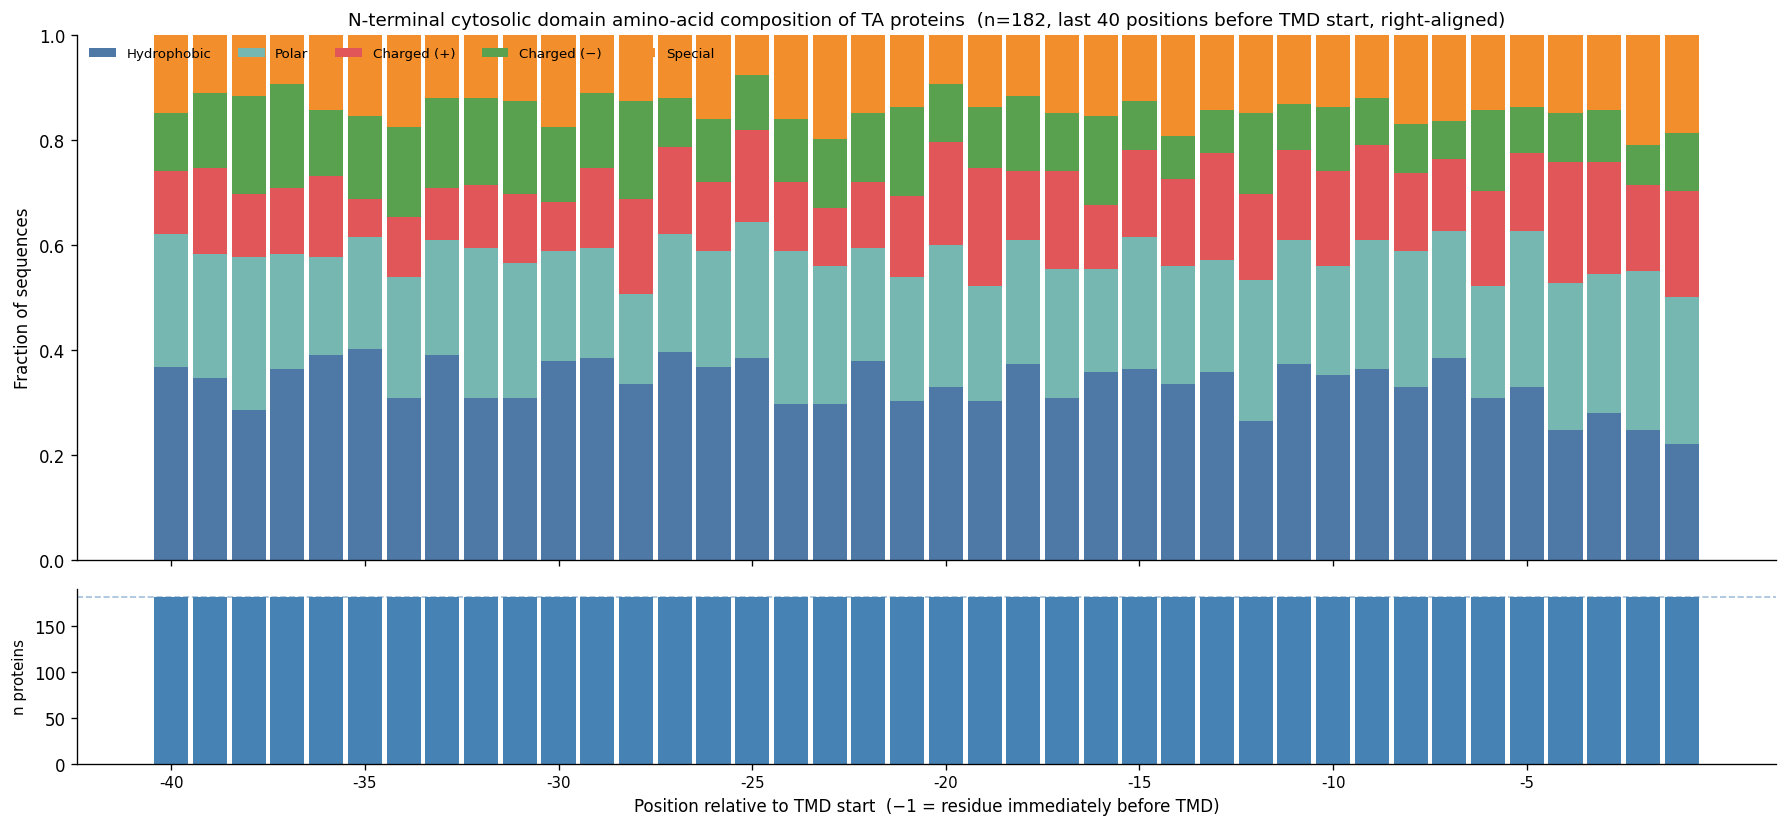


Per-position physico-chemical fractions (last 40 positions before TMD, right-aligned):


,Hydrophobic,Polar,Charged (+),Charged (−),Special,n
Position,,,,,,
-40,0.368,0.253,0.121,0.110,0.148,182
-39,0.346,0.236,0.165,0.143,0.110,182
-38,0.286,0.291,0.121,0.187,0.115,182
-37,0.363,0.220,0.126,0.198,0.093,182
-36,0.390,0.187,0.154,0.126,0.143,182
-35,0.401,0.214,0.071,0.159,0.154,182
-34,0.308,0.231,0.115,0.170,0.176,182
-33,0.390,0.220,0.099,0.170,0.121,182
-32,0.308,0.286,0.121,0.165,0.121,182


In [25]:
# ── Per-position amino-acid composition of N-terminal cytosolic domain ─────────
# Sequences are right-aligned to the TMD start: position −1 = residue immediately
# before the TMD, position −WINDOW_SHOW = furthest-upstream position shown.

AA_GROUPS = {
    "Hydrophobic":  list("AVILMFYW"),
    "Polar":        list("STNQ"),
    "Charged (+)":  list("KRH"),
    "Charged (−)":  list("DE"),
    "Special":      list("CGP"),
}
GROUP_COLORS = {
    "Hydrophobic":  "#4e79a7",
    "Polar":        "#76b7b2",
    "Charged (+)":  "#e15759",
    "Charged (−)":  "#59a14f",
    "Special":      "#f28e2b",
}
ALL_AA      = list("ACDEFGHIKLMNPQRSTVWY")
WINDOW_SHOW = 40   # last N positions before TMD start to visualise

seqs_list    = list(windows.values())
max_len      = max(len(s) for s in seqs_list)
# Right-align every sequence to the TMD start (pad left with "-")
right_padded = [s.rjust(max_len, "-") for s in seqs_list]

# Compute per-position composition for the last WINDOW_SHOW positions before TMD
pos_records = []
for back in range(WINDOW_SHOW, 0, -1):
    col_idx  = max_len - back
    residues = [s[col_idx] for s in right_padded if len(s) > col_idx and s[col_idx] != "-"]
    if not residues:
        continue
    n       = len(residues)
    aa_freq = {aa: residues.count(aa) / n for aa in ALL_AA}
    grp_frac = {grp: sum(aa_freq.get(a, 0) for a in aas) for grp, aas in AA_GROUPS.items()}
    pos_records.append({"Position": -back, "n": n, **grp_frac})

comp_df = pd.DataFrame(pos_records).set_index("Position")

# ── Figure: stacked bar (top) + coverage (bottom) ─────────────────────────────
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

# Stacked proportion bars
bottom = np.zeros(len(comp_df))
for grp, color in GROUP_COLORS.items():
    vals = comp_df[grp].values
    ax_top.bar(np.arange(len(comp_df)), vals, bottom=bottom,
               label=grp, color=color, width=0.88)
    bottom += vals

ax_top.set_ylabel("Fraction of sequences", fontsize=10)
ax_top.set_ylim(0, 1)
ax_top.set_title(
    f"N-terminal cytosolic domain amino-acid composition of TA proteins  "
    f"(n={len(windows)}, last {WINDOW_SHOW} positions before TMD start, right-aligned)",
    fontsize=11,
)
ax_top.legend(loc="upper left", fontsize=8, ncol=6, frameon=False)

# Coverage bar (how many proteins contribute to each position)
ax_bot.bar(np.arange(len(comp_df)), comp_df["n"].values, color="steelblue", width=0.88)
ax_bot.set_ylabel("n proteins", fontsize=9)
ax_bot.set_xlabel("Position relative to TMD start  (−1 = residue immediately before TMD)", fontsize=10)
ax_bot.set_ylim(0, len(windows) * 1.05)
ax_bot.axhline(len(windows), color="steelblue", linestyle="--", lw=1, alpha=0.5)

# x-axis tick labels (every 5th)
positions = list(comp_df.index)
tick_positions = range(0, len(positions), 5)
ax_bot.set_xticks(list(tick_positions))
ax_bot.set_xticklabels([str(positions[i]) for i in tick_positions], fontsize=9)
ax_top.set_xticks(list(tick_positions))
ax_top.set_xticklabels([str(positions[i]) for i in tick_positions], fontsize=9)

plt.tight_layout()
plt.show()

# ── Table: physico-chemical fractions at each position ────────────────────────
print("\nPer-position physico-chemical fractions (last 40 positions before TMD, right-aligned):")
comp_df[list(AA_GROUPS.keys()) + ["n"]].round(3)
